# Global Oil Prices & Geopolitical Events(2010-2026)

This Jupyter notebook was created to analyze the current state of the Oil Market in terms of metrics such as Brent and WTI Crude Oil Prices. The data was gathered from: https://www.kaggle.com/datasets/kavyadhyani/global-oil-prices-and-geopolitical-events/data

In [1]:
# Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

First, we load the two .csv files into `DataFrame` objects.

In [2]:
events_df = pd.read_csv('../data/geopolitical_events_timeline.csv')
oil_df = pd.read_csv('../data/oil_geopolitics_dataset_2010_2026.csv')

# Events that Shaped the Oil Market

One of the datasets included in this project is an oil geopolitics dataset. It includes data about various events such as their date, the type of event that occurrect, a brief description, and the dataset author's belief on how severely the event affected the oil market.

In [5]:
# Check first few rows of the oil-related events
print(events_df.shape)
events_df.head()

(35, 4)


,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


The data above contains events that played a role in influencing the price of oil at specific points in time. It shows a description and the nature of the event, the data it occurred, as well as how much it affected oil prices. There are 35 rows, with 4 columns. Since there are only a few rows, let's look at the entirety of the data.

In [7]:
events_df

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8
5,2014-11-27,opec,OPEC maintains production despite falling prices,9
6,2015-03-26,war,Saudi-led intervention in Yemen,7
7,2016-01-16,sanctions,Iran nuclear sanctions lifted,6
8,2016-09-28,opec,OPEC Algiers agreement on production cuts,8
9,2016-11-30,opec,First OPEC+ production cut agreement,8


The current dataset contains events that occurred from the years 2010 to 2026. The creator of the dataset created a column, `event_severity` which is a subjective rating of the impact of the event on the oil market. The highest severity being a 10 and the lowest being a 6.

In [13]:
# Sanity check to ensure the last statement above is correct.
print(f"The highest event_severity is: {max(events_df['event_severity'])}")
print(f"The lowest event_severity is: {min(events_df['event_severity'])}")

The highest event_severity is: 10
The lowest event_severity is: 6


With this dataset, I want to do several things:
1. I want to convert the `date` column into three separate columns: `day`, `month`, and `year`. This will allow me to make more specific, and advanced queries.
2. I want to visualize what `event_type` has the highest impact on the Oil Market.

## Manipulating the `date` column

In [15]:
# Construct a copy of the dataset
events_df_copy = events_df
events_df_copy.head()

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8


In [19]:
events_df_copy.date.dtype

<StringDtype(storage='python', na_value=nan)>

The `date` column is a `string` data type. We convert it to a `DateTime` object.

In [23]:
oil_events_dates = pd.to_datetime(events_df_copy['date'], format="%Y-%m-%d")

In [24]:
oil_events_dates

0    2010-04-20
1    2011-02-15
2    2011-03-19
3    2012-01-23
4    2014-03-18
5    2014-11-27
6    2015-03-26
7    2016-01-16
8    2016-09-28
9    2016-11-30
10   2017-06-05
11   2018-05-08
12   2019-09-14
13   2020-01-03
14   2020-03-08
15   2020-04-20
16   2021-03-23
17   2021-10-04
18   2022-02-24
19   2022-03-08
20   2022-06-01
21   2022-12-05
22   2023-04-02
23   2023-10-07
24   2024-01-12
25   2024-04-14
26   2024-08-26
27   2024-10-01
28   2025-02-20
29   2025-06-10
30   2025-10-28
31   2025-11-18
32   2026-02-28
33   2026-03-01
34   2026-03-09
Name: date, dtype: datetime64[us]

Now we replace the `date` column with our new column.

In [ ]:
events_df_copy['date'] = oil_events_dates
events_df_copy

,date,event_type,event_description,event_severity
0,2010-04-20,disaster,Deepwater Horizon oil spill,7
1,2011-02-15,war,Libyan Civil War begins,9
2,2011-03-19,war,NATO intervention in Libya,9
3,2012-01-23,sanctions,EU embargo on Iranian oil imports,8
4,2014-03-18,annexation,Russia annexes Crimea,8
5,2014-11-27,opec,OPEC maintains production despite falling prices,9
6,2015-03-26,war,Saudi-led intervention in Yemen,7
7,2016-01-16,sanctions,Iran nuclear sanctions lifted,6
8,2016-09-28,opec,OPEC Algiers agreement on production cuts,8
9,2016-11-30,opec,First OPEC+ production cut agreement,8


In [27]:
events_df_copy.dtypes

date                 datetime64[us]
event_type                      str
event_description               str
event_severity                int64
dtype: object

In [ ]:
events = events_df[['event_type', 'event_severity']]
counts = events.groupby('event_type')
counts

[('annexation',
     event_type  event_severity
  4  annexation               8),
 ('attack',
     event_type  event_severity
  12     attack              10),
 ('blockade',
     event_type  event_severity
  26   blockade               8
  34   blockade              10),
 ('blockage',
     event_type  event_severity
  16   blockage               8),
 ('conflict',
     event_type  event_severity
  13   conflict               9
  24   conflict               8
  25   conflict               9
  27   conflict               8
  28   conflict               8
  32   conflict              10),
 ('diplomatic_crisis',
             event_type  event_severity
  10  diplomatic_crisis               6),
 ('disaster',
    event_type  event_severity
  0   disaster               7),
 ('energy_crisis',
         event_type  event_severity
  17  energy_crisis               7),
 ('market_crash',
        event_type  event_severity
  15  market_crash              10),
 ('market_shift',
        event_type  even

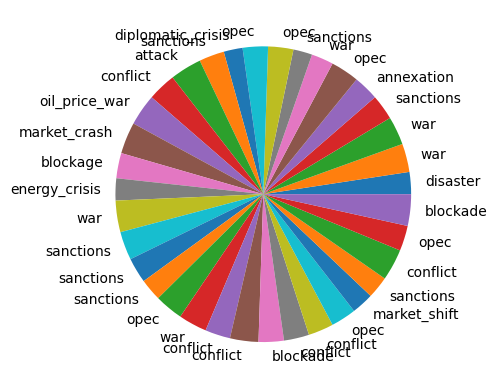

In [104]:
fig, ax = plt.subplots()
ax.pie(events['event_severity'], labels=events['event_type']);